Using CIFAR-10 dataset

cifar-10 dataset contains 60000 images of 10 classes.Each class cotaining 6000 images. 50000 images for training and 10000 images for testing. The classes are compltely mutually exclusive

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import tensorflow as tf
from tensorflow.keras import datasets,layers,models #using tensorflow we are calling an api called keras which has many datasets in it

C:\Users\ketha\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
#from libraries we are importing modules
#datasets module-provides access to many preloaded datasets commonly used in ml and dl tasks
#layers module-contains many nn layers like dense,conv2d,maxpooling2d,dropout
#models modules-provides tools to define and manages models like Sequential

In [3]:
(train_images,train_labels),(test_images,test_labels)=datasets.cifar10.load_data()

C:\Users\ketha\anaconda3\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


In [4]:
type(train_images)

numpy.ndarray

In [5]:
type(test_images)

numpy.ndarray

In [6]:
train_images.shape #50k images,each having 32-height,32-width,3-channels. If its a grey scale we can drop 3

(50000, 32, 32, 3)

In [7]:
test_images.shape

(10000, 32, 32, 3)

In [8]:
train_labels.shape

(50000, 1)

In [9]:
train_images[0].shape # each having;32-height,32-layers,each layer having 3-channels

(32, 32, 3)

In [10]:
train_images[0]

array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]

In [11]:
train_images[0][0] #layer 1 of first training sample image

array([[ 59,  62,  63],
       [ 43,  46,  45],
       [ 50,  48,  43],
       [ 68,  54,  42],
       [ 98,  73,  52],
       [119,  91,  63],
       [139, 107,  75],
       [145, 110,  80],
       [149, 117,  89],
       [149, 120,  93],
       [131, 103,  77],
       [125,  99,  76],
       [142, 115,  91],
       [144, 112,  86],
       [137, 105,  79],
       [129,  97,  71],
       [137, 106,  79],
       [134, 106,  76],
       [124,  97,  64],
       [139, 113,  78],
       [139, 112,  75],
       [133, 105,  69],
       [136, 105,  74],
       [139, 108,  77],
       [152, 120,  89],
       [163, 131, 100],
       [168, 136, 108],
       [159, 129, 102],
       [158, 130, 104],
       [158, 132, 108],
       [152, 125, 102],
       [148, 124, 103]], dtype=uint8)

In [12]:
image=train_images[12]

Extracting RGB channels respectively:

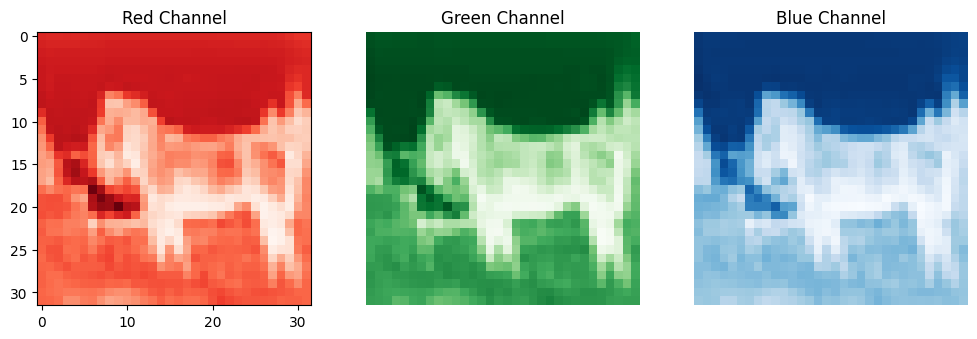

In [13]:
red=image[:,:,0] #extracting red channel
green=image[:,:,1]
blue=image[:,:,2]

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(red,cmap='Reds')
plt.title("Red Channel")

plt.subplot(1, 3, 2)
plt.imshow(green, cmap='Greens')
plt.title("Green Channel")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(blue, cmap='Blues')
plt.title("Blue Channel")
plt.axis('off')

plt.show()

In [14]:
red

array([[164, 162, 162, ..., 157, 153, 153],
       [168, 166, 166, ..., 164, 160, 158],
       [172, 170, 171, ..., 168, 165, 163],
       ...,
       [123, 117, 112, ..., 117,  95, 120],
       [120, 116, 112, ..., 126, 120, 120],
       [121, 120, 116, ..., 124, 124, 120]], shape=(32, 32), dtype=uint8)

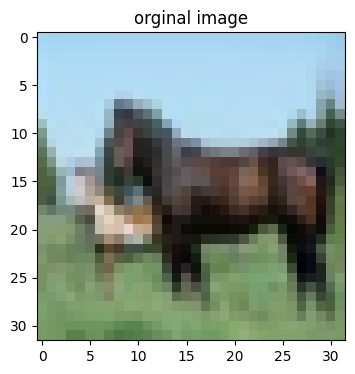

In [15]:
plt.figure(figsize=(12, 4))
plt.imshow(train_images[12])
plt.title("orginal image")
plt.show()

In [16]:
np.unique(train_labels) #10 unique classes ,label encoded to 0-9

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

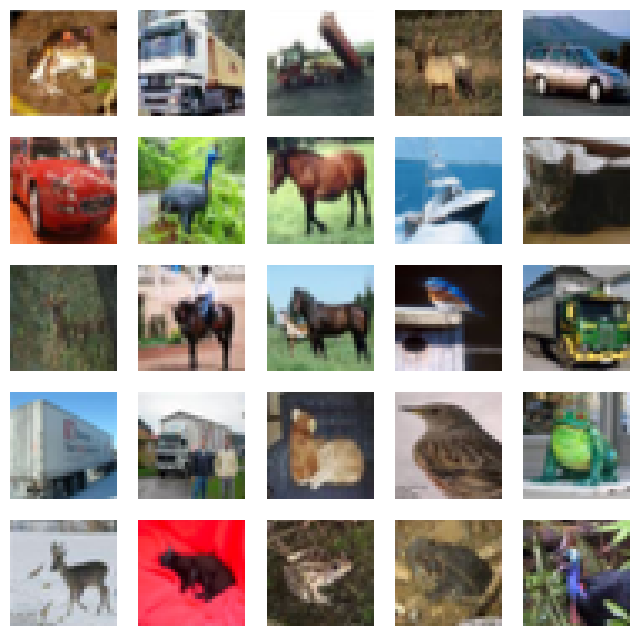

In [17]:
classnames=['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
plt.figure(figsize=(8,8))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(train_images[i])
    plt.axis('off')
    plt.xlabel(classnames[train_labels[i][0]]) #[i][0] becoz each label is again stored in a array
plt.show()

In [18]:
train_labels 

array([[6],
       [9],
       [9],
       ...,
       [9],
       [1],
       [1]], shape=(50000, 1), dtype=uint8)

In [19]:
pip install opencv-python #library in python that is used to import images from our computer files

Note: you may need to restart the kernel to use updated packages.


ERROR: Invalid requirement: '#library': Expected package name at the start of dependency specifier
    #library
    ^


In [20]:
import cv2


In [21]:
image=cv2.imread("C:\\Users\\ketha\\OneDrive\\Desktop\\lenna.jpg") #cv2.imread is a function from the OpenCV library (Python) used to read/load an image from a file into memory.

OpenCV reads images in BGR order, not RGB (opposite of most libraries)

In [22]:
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # convert BGR to RGB for display

In [23]:
### Define the filters (kernels)
#dictionary oof filters
filters = {
    'Original': np.array([[1,0,0], [0,1,0], [0,0,1]]),  # original image - leaves the image unchanged

    'Edge Detection': np.array([[-1,-1,-1],
                                [-1, 8,-1],
                                [-1,-1,-1]]),  # highlights regions with sharp changes in pixel density

    'Sharpen': np.array([[ 0,-1, 0],
                         [-1, 5,-1],
                         [ 0,-1, 0]]),  # enhances edges and details

    'Blur': np.array([[1/16, 2/16, 1/16],
                      [2/16, 4/16, 2/16],
                      [1/16, 2/16, 1/16]]),  # smoothing filter

    'Emboss': np.array([[-2,-1,0],
                        [-1, 1,1], #creates 3d like filter
                        [ 0, 1,2]])
}

In [24]:
filtered_images={}
filtered_images['Orginal']=image
for name,kernel in filters.items():
    if name=='Orginal':
        continue
    #filter application step
    filtered=cv2.filter2D(image,-1,kernel) #image-i/p,-1=same depth as i/p image(pixel val range=0-255),kernel=filter to be applied
    filtered_images[name]=filtered #stores the filtered images into this dictionary called filtered images

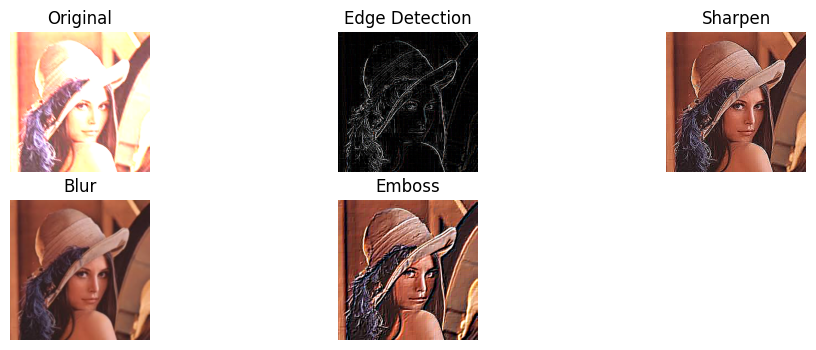

In [25]:
plt.figure(figsize=(12,4))
i=1
for name,kernel in filters.items():
    plt.subplot(2,3,i)
    plt.imshow(filtered_images[name])
    plt.title(name)
    plt.axis('off')
    i=i+1
plt.show()

creating convolutional base for the model

conv1d-text,conv2d-images(params-filters,kernel size..etc)

In [33]:
model=models.Sequential() #so that,all the layers of the model are in sequence
model.add(layers.Conv2D(filters=32,kernel_size=(3,3),activation='relu',input_shape=(32,32,3))) #first 2d convolution layer with 32 filters
model.add(layers.MaxPooling2D((2,2)))#max pooling layer with pool size 2*2 top reduce the spatial dimensions
model.add(layers.Conv2D(filters=64,kernel_size=(3,3),activation='relu',input_shape=(32,32,3))) #another 2d convolution layer with 664 filters
model.add(layers.MaxPooling2D((2,2)))#max pooling layer with pool size 2*2 top reduce the spatial dimensions

In [29]:
#pip install pydot

Note: you may need to restart the kernel to use updated packages.


In [34]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)                    │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 19,392 (75.75 KB)

 Trainable params: 19,392 (75.75 KB)

 Non-trainable params: 0 (0.00 B)

cov2d 1st layer-output shape=(30*30) for each of 32 filters

height and width of feature map can be calculate thru formulas to crosscheck